# 07 — Séries temporelles & prévision

**Objectif (data science).** Analyser la dynamique de la production scientifique
de l'UGA : tendance (CAGR, régression linéaire), trajectoire de l'accès ouvert,
et **prévision** à court terme (lissage exponentiel de Holt). Données réelles
OpenAlex, agrégées en direct.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from lib import set_seeds, OpenAlexClient, load_mart
from lib.viz import new_axes, BRAND, ACCENT

set_seeds()
oa = OpenAlexClient()

## 1. Série annuelle de production (corpus complet)

L'agrégation `group_by` par année donne le volume complet en un appel. On
écarte l'année courante (incomplète) pour l'analyse de tendance.

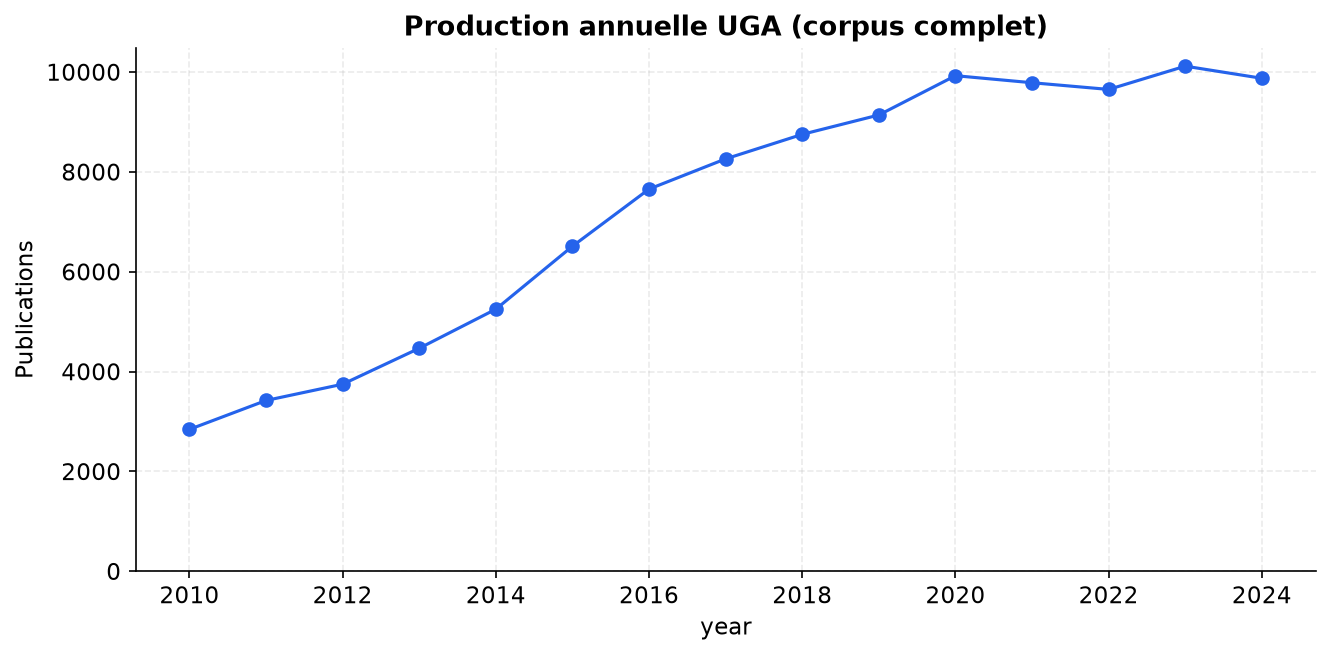

year
2010     2842
2011     3421
2012     3747
2013     4467
2014     5250
2015     6511
2016     7656
2017     8261
2018     8752
2019     9140
2020     9927
2021     9786
2022     9652
2023    10118
2024     9875
Name: count, dtype: int64

In [2]:
buckets = oa.group_by("publication_year")
series = (
    pd.DataFrame(buckets)
    .assign(year=lambda d: d["key"].astype(int))
    .query("2010 <= year <= 2024")
    .sort_values("year")
    .set_index("year")["count"]
)
ax = new_axes("Production annuelle UGA (corpus complet)", xlabel="Année", ylabel="Publications")
series.plot(ax=ax, marker="o", color=BRAND)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()
series

## 2. Tendance : CAGR et régression linéaire

Le CAGR (taux de croissance annuel moyen) résume la dynamique ; la régression
linéaire en donne la pente moyenne sur la période.

In [3]:
first, last = series.iloc[0], series.iloc[-1]
n_years = series.index[-1] - series.index[0]
cagr = (last / first) ** (1 / n_years) - 1

slope, intercept = np.polyfit(series.index, series.values, 1)
print(f"Production {series.index[0]} : {first:,} → {series.index[-1]} : {last:,}")
print(f"CAGR (taux de croissance annuel moyen) : {cagr:.1%}")
print(f"Pente de régression linéaire           : {slope:+.0f} publications/an")

Production 2010 : 2,842 → 2024 : 9,875
CAGR (taux de croissance annuel moyen) : 9.3%
Pente de régression linéaire           : +574 publications/an


## 3. Prévision par lissage exponentiel (Holt)

On projette les deux prochaines années avec un modèle de Holt (tendance
additive). C'est une prévision déterministe, reproductible et explicable.

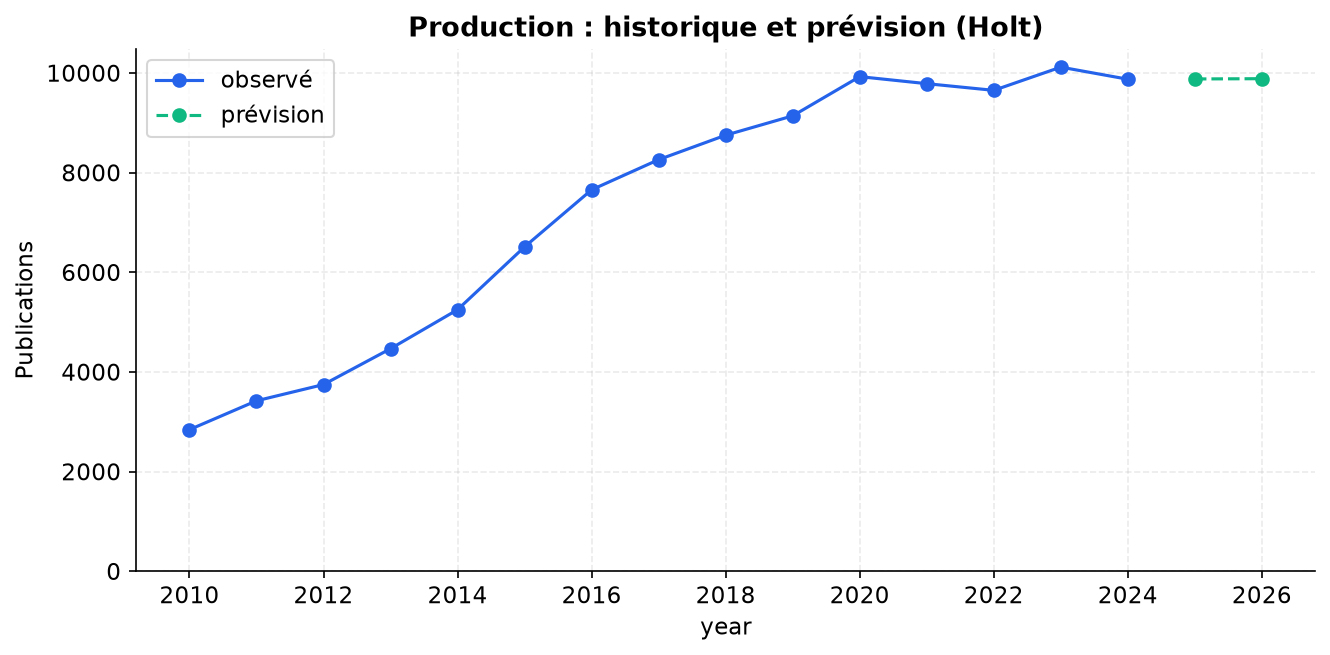

Prévision : {2025: 9881, 2026: 9886}


In [4]:
model = ExponentialSmoothing(series.astype(float), trend="add", seasonal=None, initialization_method="estimated")
fit = model.fit()
forecast = fit.forecast(2)

ax = new_axes("Production : historique et prévision (Holt)", xlabel="Année", ylabel="Publications")
series.plot(ax=ax, marker="o", color=BRAND, label="observé")
forecast.plot(ax=ax, marker="o", linestyle="--", color=ACCENT, label="prévision")
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()
print("Prévision :", {int(y): int(round(v)) for y, v in forecast.items()})

## 4. Trajectoire de l'accès ouvert

On confronte la part d'accès ouvert par année (mart `overview`) à la tendance
de production : l'ouverture progresse fortement sur la décennie.

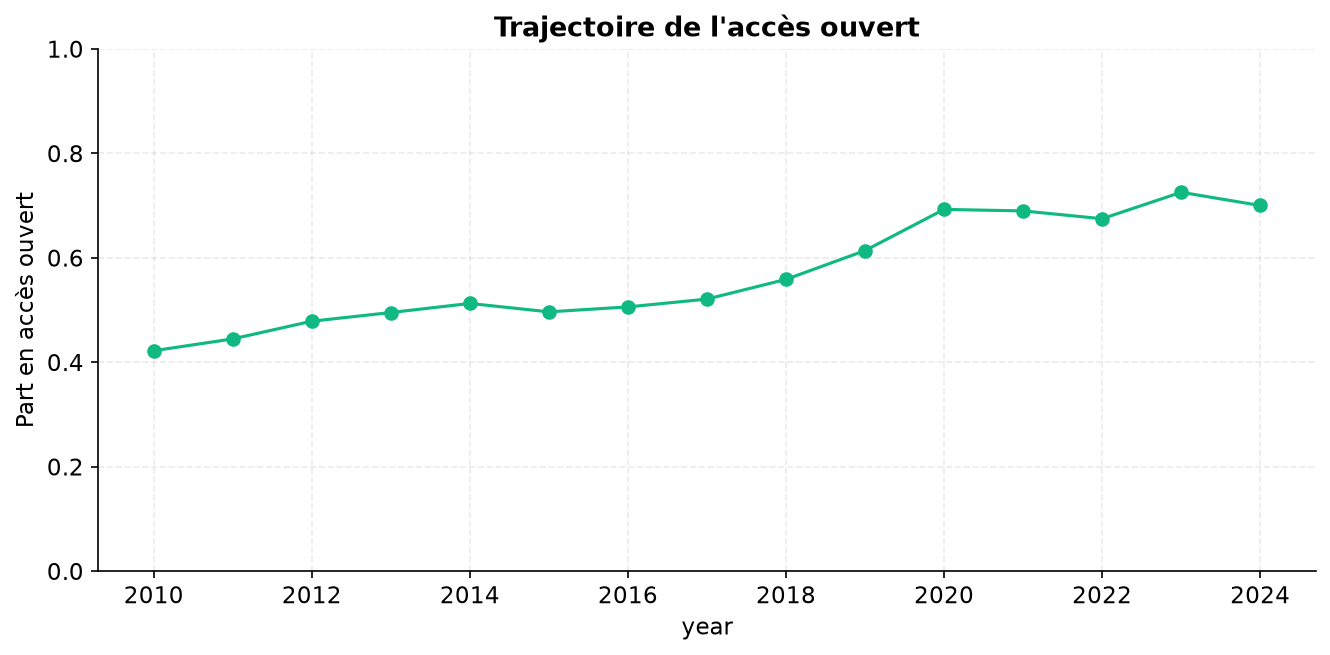

Accès ouvert : 42% (2010) → 70% (2024)


In [5]:
overview = load_mart("overview")
oa_series = pd.DataFrame(overview["oaByYear"]).query("2010 <= year <= 2024").set_index("year")["oaShare"]
ax = new_axes("Trajectoire de l'accès ouvert", xlabel="Année", ylabel="Part en accès ouvert")
oa_series.plot(ax=ax, marker="o", color=ACCENT)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()
print(f"Accès ouvert : {oa_series.iloc[0]:.0%} ({oa_series.index[0]}) → {oa_series.iloc[-1]:.0%} ({oa_series.index[-1]})")

**Lecture.** La production de l'UGA a crû régulièrement sur la décennie (CAGR
positif, pente de plusieurs centaines de publications par an), avec un plateau
sur les dernières années : la prévision de Holt prolonge donc prudemment ce
palier récent plutôt qu'une croissance soutenue. En parallèle, la part d'accès
ouvert progresse nettement, signe d'une politique de science ouverte effective.

Les années 2025-2026, incomplètes à la date d'exécution, sont volontairement
exclues de l'ajustement pour ne pas introduire de fausse rupture de tendance.